In [5]:
pip install pandas numpy matplotlib seaborn tensorflow scikit-learn

    index        date   open   high    low  close    volume  Name
0  390198  2013-02-08  27.35  27.71  27.31  27.55  33318306  MSFT
1  390199  2013-02-11  27.65  27.92  27.50  27.86  32247549  MSFT
2  390200  2013-02-12  27.88  28.00  27.75  27.88  35990829  MSFT
3  390201  2013-02-13  27.93  28.11  27.88  28.03  41715530  MSFT
4  390202  2013-02-14  27.92  28.06  27.87  28.04  32663174  MSFT
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   1259 non-null   int64  
 1   date    1259 non-null   object 
 2   open    1259 non-null   float64
 3   high    1259 non-null   float64
 4   low     1259 non-null   float64
 5   close   1259 non-null   float64
 6   volume  1259 non-null   int64  
 7   Name    1259 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 78.8+ KB
None
               index         open         high          low 

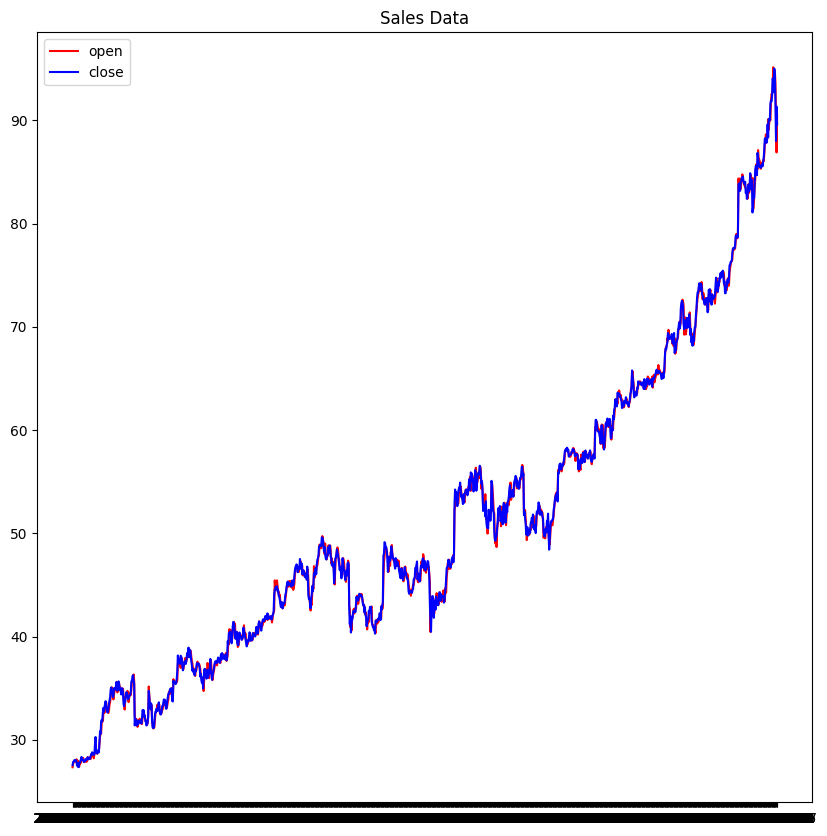

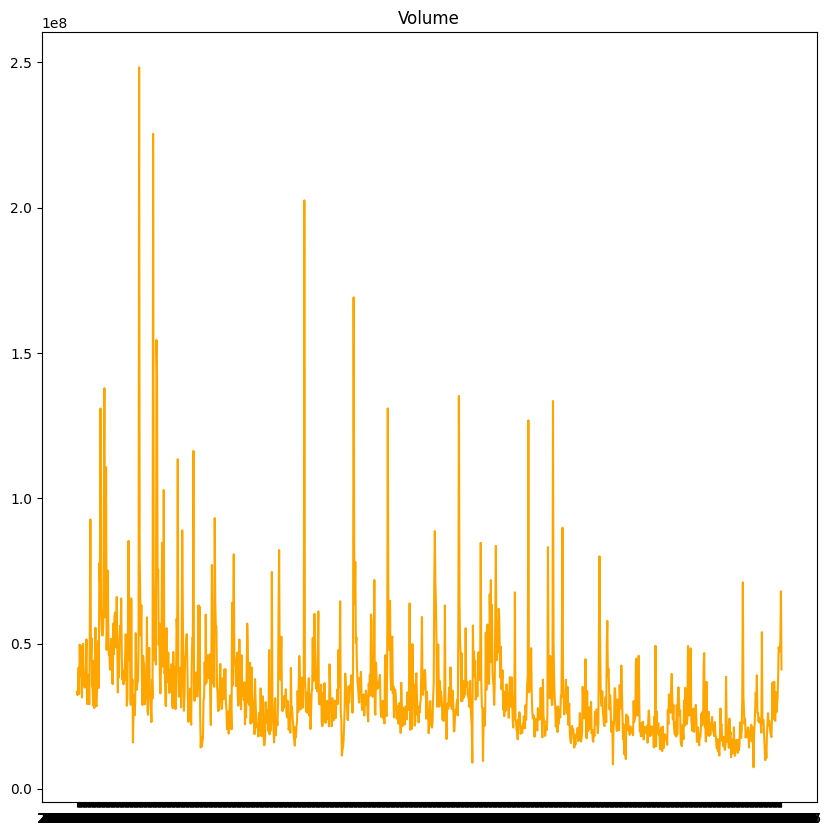

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 0.2373 - root_mean_squared_error: 0.3633
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.1310 - root_mean_squared_error: 0.1751
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.1149 - root_mean_squared_error: 0.1586
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.1129 - root_mean_squared_error: 0.1537
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.1123 - root_mean_squared_error: 0.1560
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 158ms/step - loss: 0.1127 - root_mean_squared_error: 0.1550
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 0.1068 - root_mean_squared_error: 0.1490
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 0.1062 - root_mean_squared_error: 0.1469
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.1053 - root_mean_squared_error: 0.1465
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.1013 - root_mean_squared_error: 0.139

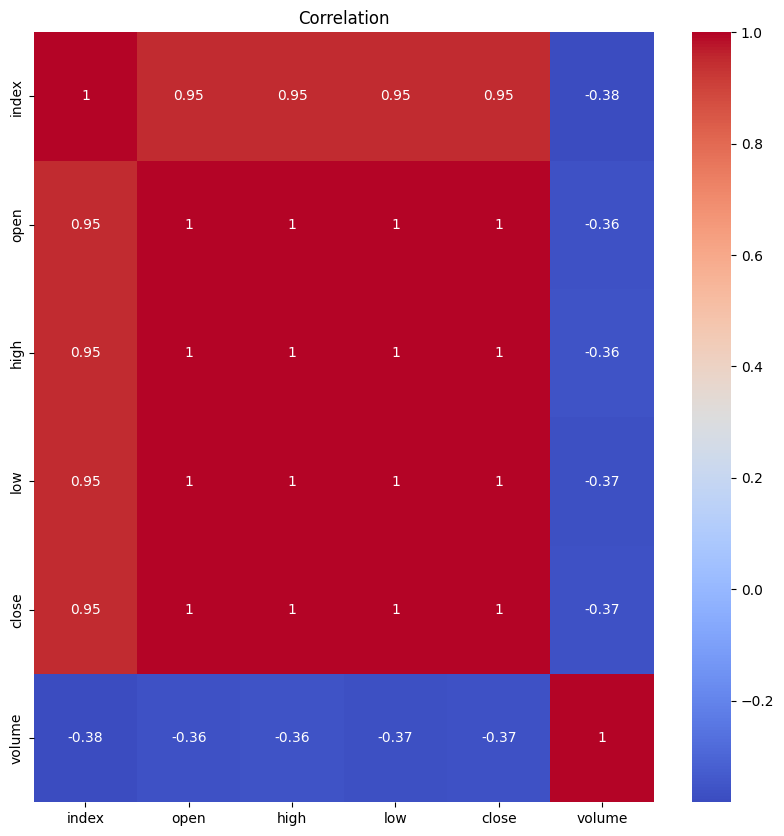

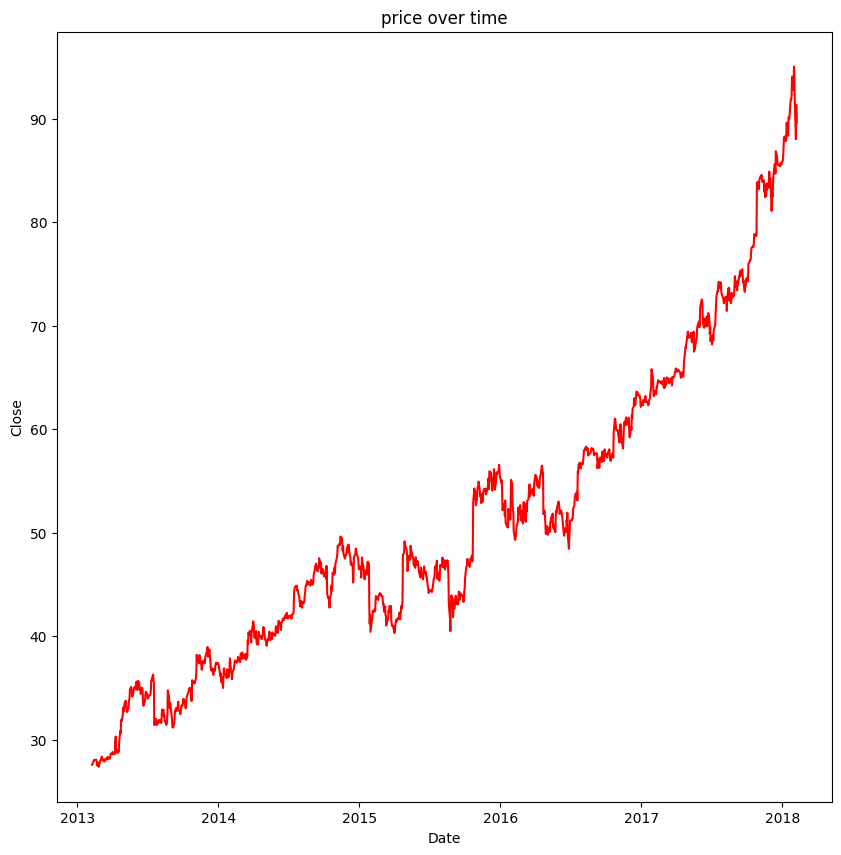

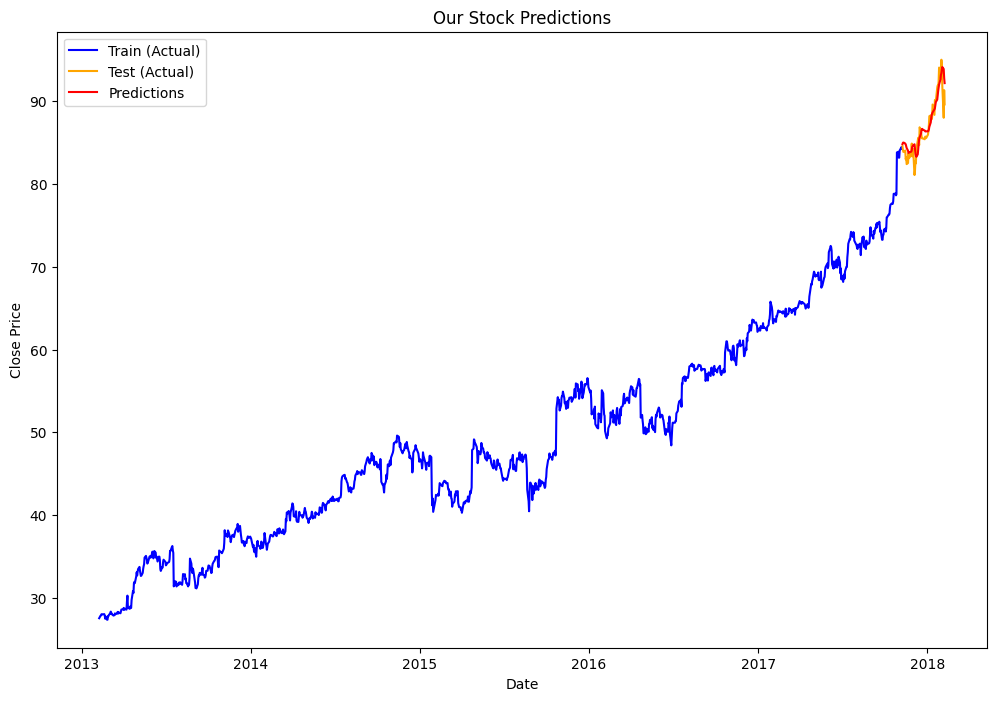

In [ ]:
# imports

from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import os
from datetime import datetime

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

data = pd.read_csv("MicrosoftStock.csv")
print(data.head())
print(data.info())
print(data.describe())


# initial data visualization
# plot - 1 open and close prices of time
plt.figure(figsize = (10,10))
plt.plot(data['date'], data['open'], label = 'open', color = 'red')
plt.plot(data['date'], data['close'], label = 'close', color = 'blue')
plt.title('Sales Data')
plt.legend()
plt.show()

# plot - 2 trading outliers
plt.figure(figsize = (10,10))
plt.plot(data['date'], data['volume'], label = 'volume', color = 'orange')
plt.title('Volume')
plt.show()

# drop non-numeric columns
numeric_data = data.select_dtypes(include = ["int64","float64"])

# plot - 3 check for correlation
plt.figure(figsize = (10,10))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.title('Correlation')

# convert the data into datetime
data['date'] = pd.to_datetime(data['date'])
prediction = data.loc[
    (data['date'] > datetime(2013,1,1)) &
    (data['date'] < datetime(2018,1,1))
]

plt.figure(figsize = (10,10))
plt.plot(data['date'], data['close'], color = 'red')
plt.xlabel('Date')
plt.ylabel('Close')
plt.title('price over time')

# prepare for the LSTM model
stock_close = data.filter(["close"])
dataset = stock_close.values  # convert to numpy array
training_data_len = int(np.ceil(len(dataset) * 0.95))

# Preprocessing Stages
scaler = StandardScaler()
scaled_data = scaler.fit_transform(dataset)

training_data = scaled_data[:training_data_len]  # 95% of all out data

X_train, y_train = [], []

# Create a sliding window for our stock (60 days)
for i in range(60, len(training_data)):
    X_train.append(training_data[i - 60:i, 0])
    y_train.append(training_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Build the Model
model = keras.models.Sequential()

# First Layer
model.add(keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)))

# Second Layer
model.add(keras.layers.LSTM(64, return_sequences=False))

# 3rd Layer (Dense)
model.add(keras.layers.Dense(128, activation="relu"))

# 4th Layer (Dropout)
model.add(keras.layers.Dropout(0.5))

# Final Output Layer
model.add(keras.layers.Dense(1))

model.summary()
model.compile(optimizer="adam",
              loss="mae",
              metrics=[keras.metrics.RootMeanSquaredError()])

training = model.fit(X_train, y_train, epochs=20, batch_size=32)

# Prep the test data
test_data = scaled_data[training_data_len - 60:]
X_test, y_test = [], dataset[training_data_len:]

for i in range(60, len(test_data)):
    X_test.append(test_data[i - 60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Make a Prediction
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

# Plotting data
train = data[:training_data_len]
test = data[training_data_len:]

test = test.copy()

test['Predictions'] = predictions

plt.figure(figsize=(12, 8))
plt.plot(train['date'], train['close'], label="Train (Actual)", color='blue')
plt.plot(test['date'], test['close'], label="Test (Actual)", color='orange')
plt.plot(test['date'], test['Predictions'], label="Predictions", color='red')
plt.title("Our Stock Predictions")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()